Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0342
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.1682e-04
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6647e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2922e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6558e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4714e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.0048e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.4803e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.8920e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.0823e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5282e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.0112e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7831e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7035e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━

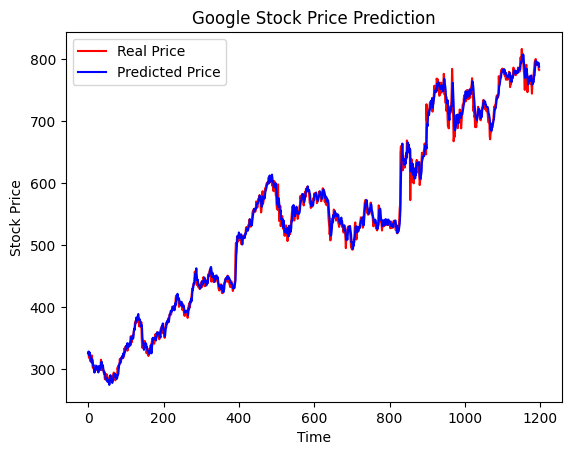

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# Load dataset
data = pd.read_csv("/content/Google_Stock_Price_Train.csv")

# Take Open price column
dataset = data[['Open']].values

# Scale data
scaler = MinMaxScaler(feature_range=(0,1))
dataset = scaler.fit_transform(dataset)

# Create training data
X_train = []
y_train = []

for i in range(60, len(dataset)):
    X_train.append(dataset[i-60:i, 0])
    y_train.append(dataset[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for RNN
X_train = np.reshape(X_train,
                     (X_train.shape[0],
                      X_train.shape[1],
                      1))

# Build RNN model
model = Sequential()

model.add(SimpleRNN(50,
                    activation='tanh',
                    input_shape=(X_train.shape[1],1)))

model.add(Dense(1))

# Compile
model.compile(optimizer='adam',
              loss='mean_squared_error')

# Train
history = model.fit(X_train,
                    y_train,
                    epochs=20,
                    batch_size=32)

# Predict
predicted = model.predict(X_train)

# Convert back to original values
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_train.reshape(-1,1))

# Plot graph
plt.plot(real, color='red',
         label='Real Price')

plt.plot(predicted,
         color='blue',
         label='Predicted Price')

plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()
plt.show()